In [1]:
import transformers
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from plotly import express as exp
import pprint
import ast
import collections
from wordcloud import WordCloud
from nltk.corpus import stopwords
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display, HTML

In [2]:
game_desc = pd.read_csv("/kaggle/input/steam-games-reviews-and-rankings/games_description.csv")
game_rank = pd.read_csv("/kaggle/input/steam-games-reviews-and-rankings/games_ranking.csv")
game_review = pd.read_csv("/kaggle/input/steam-games-reviews-and-rankings/steam_game_reviews.csv", low_memory=False)

# Data Cleaning and Pre-Processing

In [3]:
game_desc.overall_player_rating = game_desc.overall_player_rating.apply(lambda x: 'Very Negative' if ' user reviews' in x else x)

In [4]:
game_review[['username','number_of_games']] = game_review.username.str.extract(r'(.+)(?:\n(\d+))?')

In [5]:
game_desc['releaseYear'] = pd.to_datetime(game_desc.release_date, format='mixed').apply(lambda x: x.year)

In [6]:
game_desc.columns

Index(['name', 'short_description', 'long_description', 'genres',
       'minimum_system_requirement', 'recommend_system_requirement',
       'release_date', 'developer', 'publisher', 'overall_player_rating',
       'number_of_reviews_from_purchased_people', 'number_of_english_reviews',
       'link', 'releaseYear'],
      dtype='object')

# EDA

In [7]:
rating_count = game_desc.overall_player_rating.value_counts()
exp.bar(x=rating_count.keys(), y=rating_count.values, title='Rating distribution in the data')

In [8]:
exp.histogram(x=game_desc.releaseYear,nbins=30)

In [9]:
stopwordsgenres = [ast.literal_eval(x) for x in game_desc.genres]
genres = [x for xs in game_desc.genres for x in xs]

genres_count = collections.Counter(genres)
genres_count = genres_count.most_common(15)
keys,values = zip(*genres_count)

exp.pie(names=keys, values=values)

In [10]:
publisher = [ast.literal_eval(x) for x in game_desc.publisher]
publisher = [x for xs in publisher for x in xs]


publisher_count = collections.Counter(publisher)
top_publishers = publisher_count.most_common(10)

top_publishers_dict = dict(top_publishers)
others_count = sum(count for publisher, count in publisher_count.items() if publisher not in top_publishers_dict)

top_publishers_dict['Others'] = others_count

exp.pie(names=top_publishers_dict.keys(), values=top_publishers_dict.values())

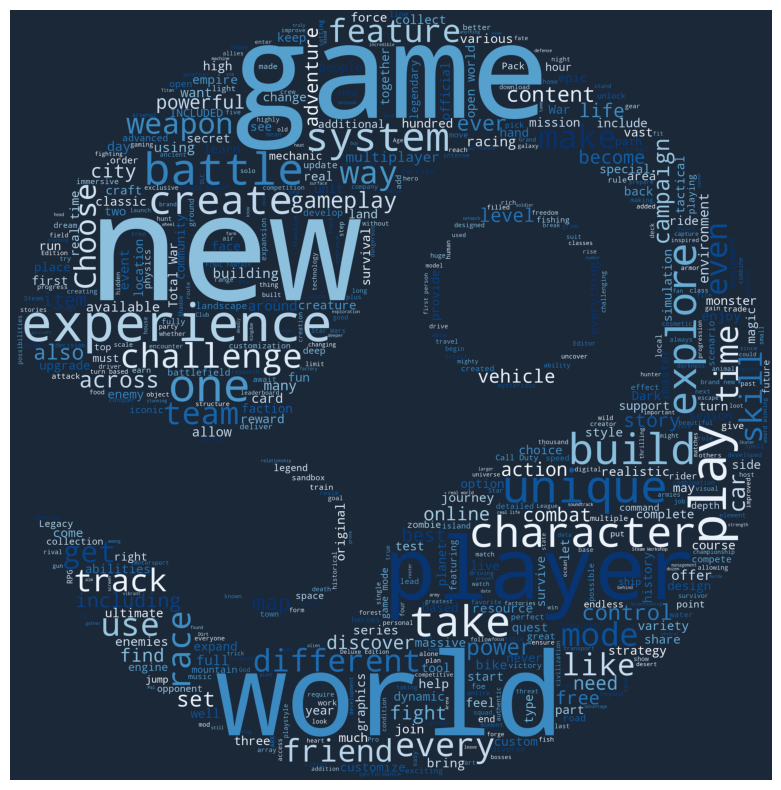

In [11]:
response = requests.get('https://cdn.freebiesupply.com/logos/large/2x/steam-1-logo-png-transparent.png')
img = Image.open(BytesIO(response.content))
img_bg = Image.new("RGB", img.size, (255,255,255))
img_bg.paste(img,img)
text = ' '.join([x.replace("About This Game","") for x in game_desc.long_description])
wc = WordCloud(mask = np.array(img_bg), colormap = 'Blues', width = 1000, height = 1000, max_words=600,
               background_color='#1b2838', min_word_length=3, stopwords=stopwords.words('english')).generate(text)
fig = plt.figure(figsize=(10, 10))
plt.axis("off")
plt.imshow(wc)

## Most Funny Reviews

In [12]:
funniest_review = game_review.sort_values('funny', ascending=False)
for index, row in funniest_review.iloc[:11].iterrows():
    display(HTML(f'<h1>{row.username} ({row.funny} Funny)</h1><h4>{row.game_name}</h4><p>{row.date}</p><p>{row.review}</p>'))

## Review WordCloud

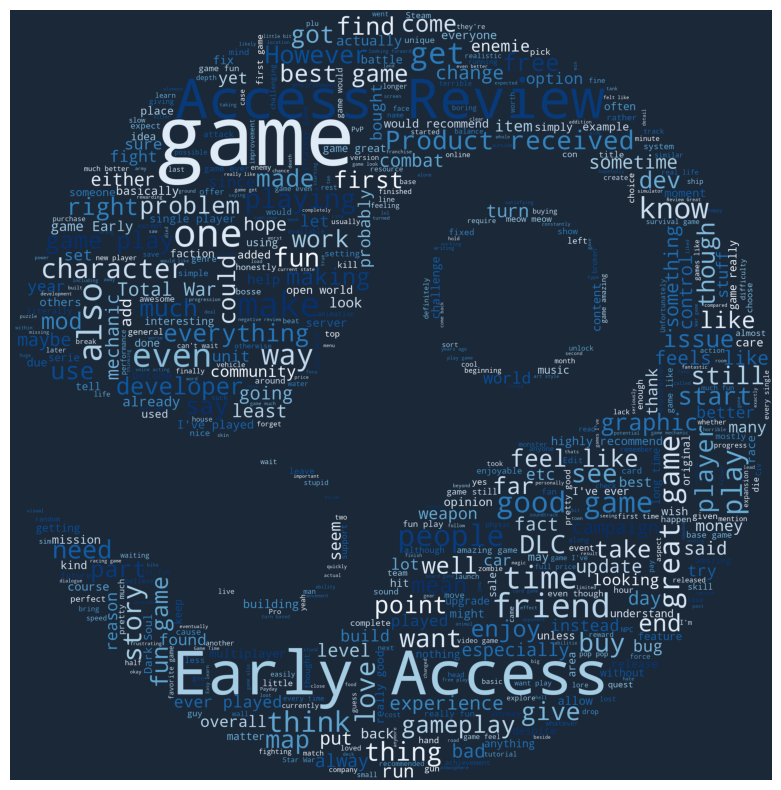

In [13]:
response = requests.get('https://cdn.freebiesupply.com/logos/large/2x/steam-1-logo-png-transparent.png')
img = Image.open(BytesIO(response.content))
img_bg = Image.new("RGB", img.size, (255,255,255))
img_bg.paste(img,img)
text = ' '.join([str(x) for x in game_review.review])
wc = WordCloud(mask = np.array(img_bg), colormap = 'Blues', width = 1000, height = 1000, max_words=600,
               background_color='#1b2838', min_word_length=3, stopwords=stopwords.words('english')).generate(text)
fig = plt.figure(figsize=(10, 10))
plt.axis("off")
plt.imshow(wc)

<div class="alert alert-block alert-warning">
<h1>🚧 Work Under Construction 🚧</h1>
</div>